In [1]:
# all the libraries i have used
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import pandas as pd
import pickle as pkl

In [2]:
# loading train dataset the same way as base task
!pip install -q gdown

import gdown

file_id = "11n00bAs7TU3H_7GE86tia5rsB-ax4XXy"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.csv", quiet=True)

df_train = pd.read_csv("data.csv")
df_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df_test = pd.read_csv('https://drive.google.com/uc?id=1bvbOveIMLFbU2Vnw6LwghYyxK1caH4C1')
df_test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# defining training and test sets
x_train = df_train.iloc[:, 1:].values
y_train = df_train.iloc[:, 0].values

x_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

In [5]:
# normalising bw 0 and 1
x_train = x_train / 255
x_test = x_test / 255

In [6]:
# converting to torch
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

In [7]:
# turning into dataset
dataset = TensorDataset(x_train, y_train)

# spliting into train and validation dataset
train = int(0.75 * len(dataset))
val = len(dataset) - train

train_dataset, val_dataset = random_split(dataset, [train, val])

# dataloader to improve efficiency by regrouping into small batches and shuffling training set
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [8]:
# same model architecture as base task
class MyNeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        # initial part of the model
        self.base = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 16),
            nn.ReLU()
        )

        # the right branch
        self.right1 = nn.Sequential(
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, 8),
            nn.ReLU()
        )

        # the left branch
        self.left1 = nn.Sequential(
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU()
        )

        # the output layer
        self.output = nn.Sequential(
            nn.Linear(16, 10)
        )

    # defining forward pass
    def forward(self, x):

        x = self.base(x)

        # right path
        right = self.right1(x)

        # left path with skip connection
        left1 = self.left1[0](x)
        left2 = self.left1[2](self.left1[1](left1))
        left = self.left1[3](left2 + left1)

        # concatenate both branches to get single output
        combine = torch.cat([left, right], dim=1)

        return self.output(combine)

In [9]:
# training function so i dont have to rewrite same loop for each alpha value
def train_model(alpha, num_epoch=30):

    model = MyNeuralNetwork()

    # label_smoothing parameter is what changes between runs
    # alpha=0.0 means normal training, anything above adds smoothing
    loss_function = nn.CrossEntropyLoss(label_smoothing=alpha)

    # using Adam for updating weights
    optimizer = optim.Adam(model.parameters(), lr=0.0003)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epoch):

        # setting model to training mode
        model.train()
        total_loss, correct, total = 0, 0, 0

        for x_batch, y_batch in train_loader:

            # forward pass
            y_pred = model(x_batch)

            # calculating loss
            loss = loss_function(y_pred, y_batch)

            # clearing gradients from last step
            optimizer.zero_grad()

            # backward pass
            loss.backward()

            # updating weights
            optimizer.step()

            # keeping track of loss and accuracy over all batches
            total_loss += loss.item()
            correct += (torch.argmax(y_pred, 1) == y_batch).sum().item()
            total += y_batch.size(0)

        # storing average loss and accuracy for this epoch
        train_losses.append(total_loss / len(train_loader))
        train_accs.append(correct / total)

        # switching to eval mode
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0

        # no need to calculate gradients during validation
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                y_pred = model(x_batch)
                v_loss += loss_function(y_pred, y_batch).item()
                v_correct += (torch.argmax(y_pred, 1) == y_batch).sum().item()
                v_total += y_batch.size(0)

        val_losses.append(v_loss / len(val_loader))
        val_accs.append(v_correct / v_total)

        print(f"Alpha={alpha} | Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, Train Acc={train_accs[-1]:.4f}, Val Acc={val_accs[-1]:.4f}")

    return model, train_losses, val_losses, train_accs, val_accs

In [10]:
# training 4 models with different smoothing values
# alpha=0.0 is normal training, rest have label smoothing
alphas = [0.0, 0.1, 0.3, 0.5]
results = {}

for alpha in alphas:
    print(f"\n--- Training with alpha = {alpha} ---")
    model, tl, vl, ta, va = train_model(alpha)
    results[alpha] = {
        'model': model,
        'train_losses': tl,
        'val_losses': vl,
        'train_accs': ta,
        'val_accs': va
    }


--- Training with alpha = 0.0 ---
Alpha=0.0 | Epoch 1: Train Loss=1.0229, Val Loss=0.6484, Train Acc=0.6026, Val Acc=0.7631
Alpha=0.0 | Epoch 2: Train Loss=0.5811, Val Loss=0.5373, Train Acc=0.7981, Val Acc=0.8119
Alpha=0.0 | Epoch 3: Train Loss=0.5081, Val Loss=0.4872, Train Acc=0.8223, Val Acc=0.8285
Alpha=0.0 | Epoch 4: Train Loss=0.4759, Val Loss=0.4662, Train Acc=0.8327, Val Acc=0.8364
Alpha=0.0 | Epoch 5: Train Loss=0.4567, Val Loss=0.4516, Train Acc=0.8389, Val Acc=0.8405
Alpha=0.0 | Epoch 6: Train Loss=0.4416, Val Loss=0.4525, Train Acc=0.8445, Val Acc=0.8409
Alpha=0.0 | Epoch 7: Train Loss=0.4297, Val Loss=0.4336, Train Acc=0.8478, Val Acc=0.8454
Alpha=0.0 | Epoch 8: Train Loss=0.4211, Val Loss=0.4331, Train Acc=0.8508, Val Acc=0.8445
Alpha=0.0 | Epoch 9: Train Loss=0.4128, Val Loss=0.4274, Train Acc=0.8543, Val Acc=0.8492
Alpha=0.0 | Epoch 10: Train Loss=0.4068, Val Loss=0.4243, Train Acc=0.8568, Val Acc=0.8515
Alpha=0.0 | Epoch 11: Train Loss=0.4000, Val Loss=0.4159, Train 

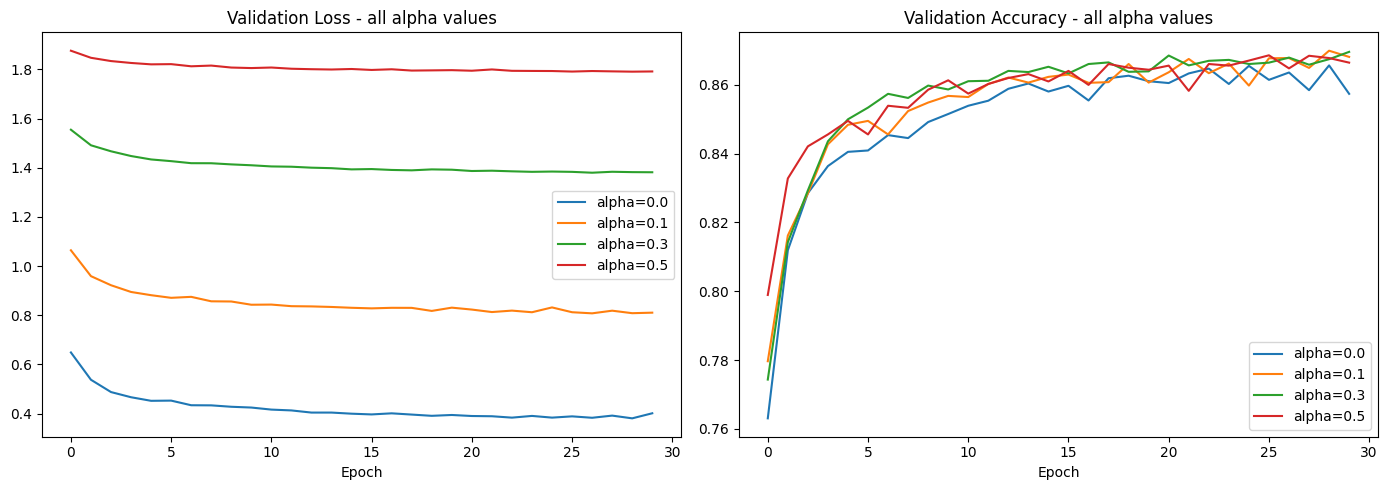

In [11]:
# comparing validation accuracy across all alpha values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for alpha in alphas:
    ax1.plot(results[alpha]['val_losses'], label=f'alpha={alpha}')
    ax2.plot(results[alpha]['val_accs'], label=f'alpha={alpha}')

ax1.set_title('Validation Loss - all alpha values')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.set_title('Validation Accuracy - all alpha values')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

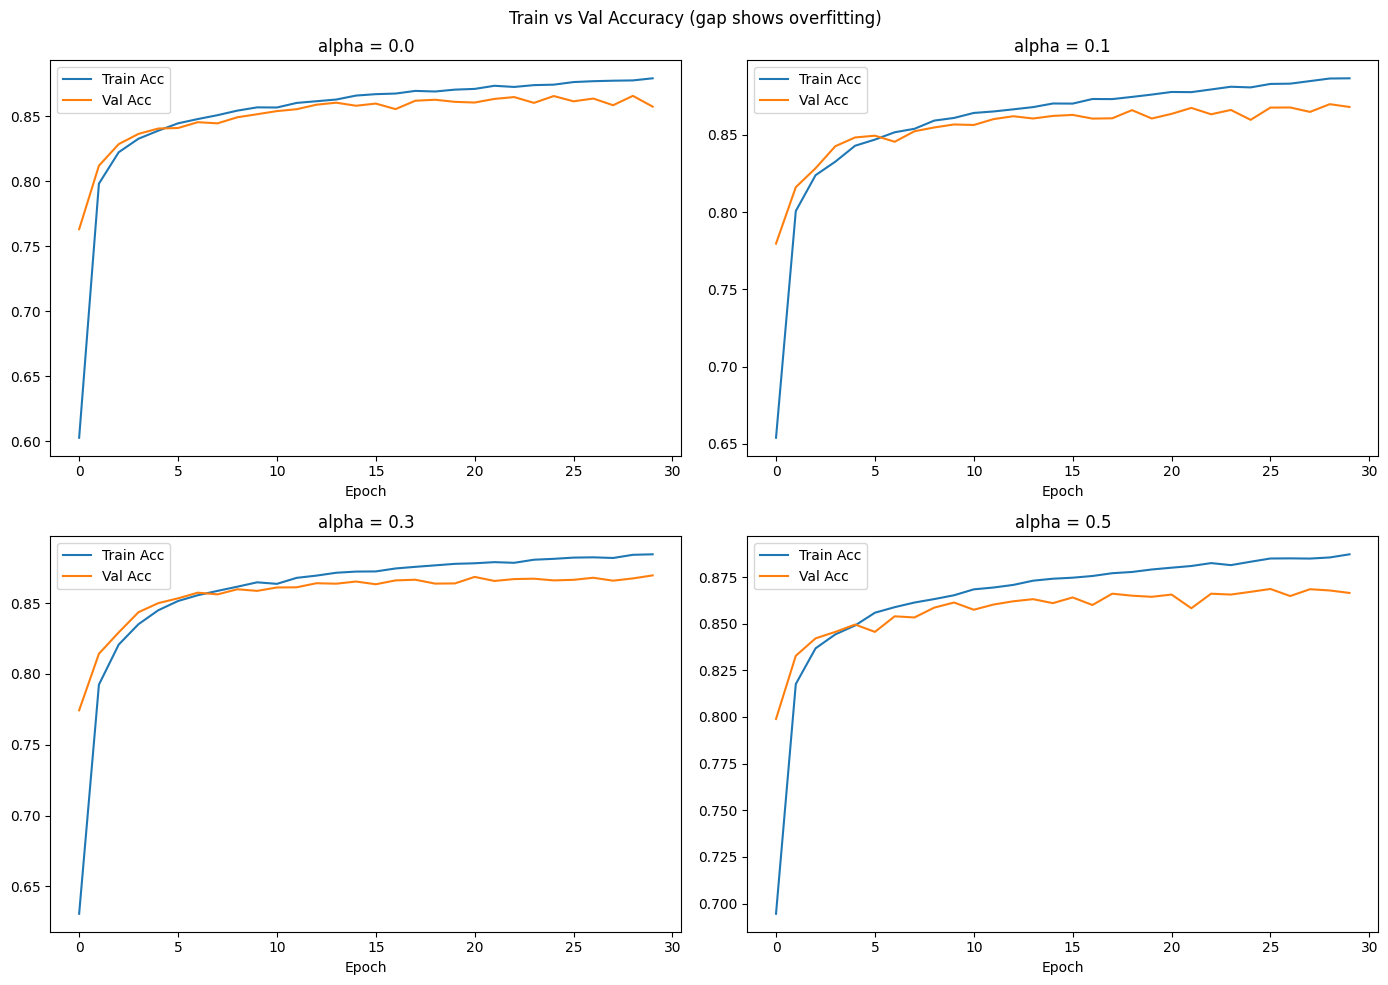

In [12]:
# observing overfitting - gap between train and val accuracy
# a large gap means the model memorised training data but didnt generalise well
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, alpha in enumerate(alphas):
    axes[i].plot(results[alpha]['train_accs'], label='Train Acc')
    axes[i].plot(results[alpha]['val_accs'], label='Val Acc')
    axes[i].set_title(f'alpha = {alpha}')
    axes[i].set_xlabel('Epoch')
    axes[i].legend()

plt.suptitle('Train vs Val Accuracy (gap shows overfitting)')
plt.tight_layout()
plt.show()

In [13]:
# class names for fashion mnist
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# analyzing prediction confidence - how sure is each model about its predictions
# softmax converts logits to probabilities, max probability = confidence
print("Average prediction confidence for each model:")
print("-" * 45)

for alpha in alphas:
    model = results[alpha]['model']
    model.eval()

    with torch.no_grad():
        logits = model(x_test)

        # converting logits to probabilities
        probs = torch.softmax(logits, dim=1)

        # max probability for each prediction = how confident the model is
        confidence = probs.max(dim=1).values.mean().item()

    print(f"alpha={alpha} → avg confidence: {confidence*100:.2f}%")

Average prediction confidence for each model:
---------------------------------------------
alpha=0.0 → avg confidence: 85.93%
alpha=0.1 → avg confidence: 78.50%
alpha=0.3 → avg confidence: 62.43%
alpha=0.5 → avg confidence: 48.38%


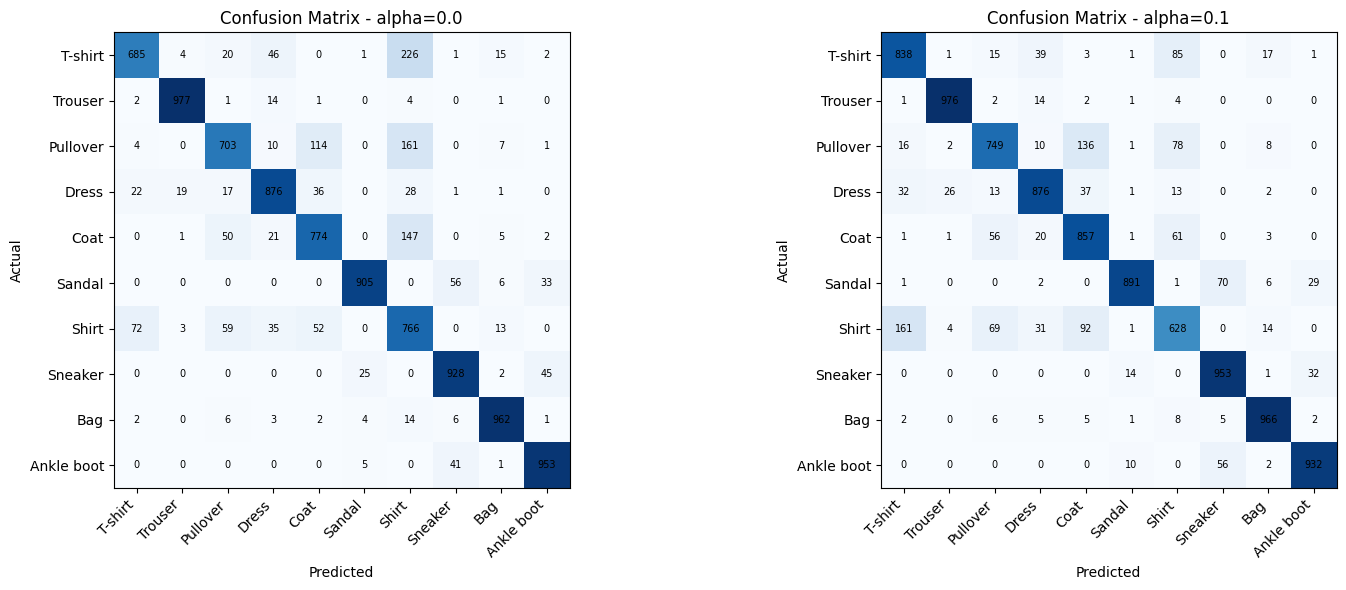

In [14]:
# studying class wise misclassifications for alpha=0.0 vs alpha=0.1
# want to see which classes get confused with which
def get_confusion(model, x, y):
    model.eval()
    confusion = np.zeros((10, 10), dtype=int)

    with torch.no_grad():
        preds = torch.argmax(model(x), dim=1).numpy()
        actual = y.numpy()

    for actual_class, predicted_class in zip(actual, preds):
        confusion[actual_class][predicted_class] += 1

    return confusion


# plotting confusion matrix for normal vs smoothed model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, alpha in zip([ax1, ax2], [0.0, 0.1]):
    conf = get_confusion(results[alpha]['model'], x_test, y_test)
    im = ax.imshow(conf, cmap='Blues')
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_title(f'Confusion Matrix - alpha={alpha}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # adding numbers inside each cell
    for i in range(10):
        for j in range(10):
            ax.text(j, i, conf[i][j], ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()

In [15]:
# final summary - comparing all models on test set
print("Final Test Accuracy Summary")
print("-" * 35)

for alpha in alphas:
    model = results[alpha]['model']
    model.eval()

    with torch.no_grad():
        preds = torch.argmax(model(x_test), dim=1).numpy()

    correct = (preds == y_test.numpy()).sum()
    acc = correct / len(y_test) * 100
    print(f"alpha={alpha} → Test Accuracy: {acc:.2f}%")

Final Test Accuracy Summary
-----------------------------------
alpha=0.0 → Test Accuracy: 85.29%
alpha=0.1 → Test Accuracy: 86.66%
alpha=0.3 → Test Accuracy: 86.66%
alpha=0.5 → Test Accuracy: 86.39%
